### Create SMET Forcing Files from HRRR-AK Data: Point Simulation the HEEN

Notebook contents 
* Temperature Lapse-rate Correction

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/heen'

## Load the HRRR Dataset

In [3]:
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
# and clip to WY2021 only 
ds = ds.sel(time=slice("2019-10-01T05:00:00", "2025-09-30T05:00:00"))
ds

<xarray.Dataset> Size: 13MB
Dimensions:       (time: 52584)
Coordinates:
    valid_time    (time) datetime64[ns] 421kB ...
    step          (time) timedelta64[ns] 421kB ...
  * time          (time) datetime64[ns] 421kB 2019-10-01T05:00:00 ... 2025-09...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 421kB ...
    pressure      (time) float64 421kB ...
    orog          (time) float64 421kB ...
    temp_surface  (time) float64 421kB ...
    swe           (time) float64 421kB ...
    snowdepth     (time) float64 421kB ...
    ...            ...
    suswrf        (time) float64 421kB ...
    sulwrf        (time) float64 421kB ...
    wind          (time) float64 421kB ...
    wind_dir      (time) float64 421kB ...
    veg           (time) float64 421kB ...
    lai           (time) float64 421kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       heen
    original_lat:    58.69652
    original_lon:    -134.86448
    utm_x:           507854.334991801
    utm_y:           6506268.082489309

HRRR to MeteIO Variable Mapping 

In [4]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [5]:
from pathlib import Path
from pyproj import Transformer

This version dealing with the timestepping, and precipiation units over that timestep

In [6]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [7]:
ds.orog.values

array([655.3125    , 655.3125    , 655.3125    , ..., 743.61348684,
       743.61348684, 743.61348684], shape=(52584,))

In [8]:
# =========================
# USER SETTINGS
# =========================
OUTFILE = Path("/home/cassie/python/models/run_snowpack/sites/heen/input/hrrrak_lapserate_WY2020-WY2025/hrrrak_lapserate_heen_WY2020-WY2025.smet")

STATION_ID = "hrrrak_lapserate_heen_WY2020-WY2025"
STATION_NAME = "HRRR-AK HEEN Point Forcing - Lapse-rate Corrected Temperature"

LAT = lat_heen
LON = lon_heen
ELEV = elevation_heen          # site elevation, m
HRRR_ELEV = 744             # HRRR-AK grid-cell elevation at HEEN, m

EPSG = 32608
TZ = 0
NODATA = -999

# Temperature lapse rate
# Positive value in degC/m; 0.0065 = 6.5 degC/km
# LAPSE_RATE = 0.0065
LAPSE_RATE = 0.006 # going to use 6 degC/km

# -------------------------
# SIMULATION TIMESTEP
# -------------------------
TIMESTEP = "1h"
TIMESTEP_SECONDS = pd.to_timedelta(TIMESTEP).total_seconds()

# =========================
# COORDINATE TRANSFORM
# =========================
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# =========================
# BUILD DATAFRAME
# =========================
time = pd.to_datetime(ds.time.values)
df = pd.DataFrame(index=time)

# =========================
# LAPSE-RATE CORRECTED TEMPERATURE
# =========================
# Formula:
# T_site = T_hrrr - lapse_rate * (site_elev - hrrr_elev)
#
# If the HRRR grid cell is higher than the site, this warms the temperature.
# If the HRRR grid cell is lower than the site, this cools the temperature.

elevation_difference = ELEV - HRRR_ELEV
temperature_correction = -LAPSE_RATE * elevation_difference

print(f"Site elevation: {ELEV:.2f} m")
print(f"HRRR elevation: {HRRR_ELEV:.2f} m")
print(f"Elevation difference, site - HRRR: {elevation_difference:.2f} m")
print(f"Temperature correction applied to HRRR TA: {temperature_correction:.2f} °C")

# Base variables
df["TA"] = ds.temp.values + temperature_correction
df["RH"] = ds.rh.values / 100.0
df["ISWR"] = ds.swrad.values
df["ILWR"] = ds.lwrad.values
df["PS"] = ds.pressure.values

# ---- Wind speed & direction ----
u = ds["10u"].values
v = ds["10v"].values

df["VW"] = np.sqrt(u**2 + v**2)
df["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0

# ---- Precipitation conversion ----
# precip_rate: kg/m²/s → mm per timestep
df["PSUM"] = ds.precip_rate.values * TIMESTEP_SECONDS

# =========================
# RESAMPLE TO MODEL TIMESTEP
# =========================
mean_vars = ["TA", "RH", "VW", "DW", "ISWR", "ILWR", "PS"]
sum_vars = ["PSUM"]

df_mean = df[mean_vars].resample(TIMESTEP).mean()
df_sum = df[sum_vars].resample(TIMESTEP).sum()

df = pd.concat([df_mean, df_sum], axis=1)

# Replace missing values
df = df.fillna(NODATA)

# =========================
# WRITE SMET
# =========================
OUTFILE.parent.mkdir(parents=True, exist_ok=True)

with open(OUTFILE, "w") as f:
    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")
    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")
    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")
    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")
    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = HRRR-AK point extraction; temperature lapse-rate corrected to site elevation\n")
    f.write(f"lapse_rate       = {LAPSE_RATE:.4f} degC m-1\n")
    f.write(f"hrrr_elevation   = {HRRR_ELEV:.2f} m\n")
    f.write(f"site_elevation   = {ELEV:.2f} m\n")
    f.write(f"ta_correction    = {temperature_correction:.3f} degC\n")

    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")

    for t, row in df.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} {row.RH:6.3f} "
            f"{row.VW:6.2f} {row.DW:6.1f} "
            f"{row.ISWR:8.1f} {row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} {row.PS:8.1f}\n"
        )

Site elevation: 548.00 m
HRRR elevation: 744.00 m
Elevation difference, site - HRRR: -196.00 m
Temperature correction applied to HRRR TA: 1.18 °C


## Create .SNO File

In [12]:
# ============================================================
# CREATE EMPTY .SNO FILE
# ============================================================

from datetime import timedelta

# ============================================================
# OUTPUT FILE
# ============================================================

OUTFILE_SNO = OUTFILE.with_suffix(".sno")

# Example:
# /home/cassie/python/models/run_snowpack/sites/tram/input/
# hrrrak_lapserate_WY2020-WY2025/
# hrrrak_lapserate_tram_WY2020-WY2025.sno

# ============================================================
# PROFILE DATE
# ============================================================

# Use the first timestamp in the forcing dataframe
# after resampling.
start_time = df.index.min()

# SNOWPACK commonly initializes one timestep after start
profile_date = pd.to_datetime(start_time) + pd.to_timedelta(TIMESTEP)

profile_date_str = profile_date.strftime("%Y-%m-%dT%H:%M")

# ============================================================
# OPTIONAL SITE PARAMETERS
# ============================================================

SLOPE_ANGLE = 38.0
SLOPE_AZI   = 0.0

SOIL_ALBEDO = 0.09
BARE_SOIL_Z0 = 0.200

CANOPY_HEIGHT = 0.00
CANOPY_LAI = 0.00
CANOPY_DIRECT_THROUGHFALL = 1.00

WIND_SCALING_FACTOR = 1.00

# ============================================================
# WRITE SNO FILE
# ============================================================

with open(OUTFILE_SNO, "w") as f:

    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    # --------------------------------------------------------
    # SITE INFORMATION
    # --------------------------------------------------------

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write("source           = HRRR-AK point extraction; temperature lapse-rate corrected to site elevation\n")
    f.write(f"lapse_rate       = {LAPSE_RATE:.4f} degC m-1\n")
    f.write(f"hrrr_elevation   = {HRRR_ELEV:.2f} m\n")
    f.write(f"site_elevation   = {ELEV:.2f} m\n")
    f.write(f"ta_correction    = {temperature_correction:.3f} K\n")

    # --------------------------------------------------------
    # SNOWPACK INITIALIZATION SETTINGS
    # --------------------------------------------------------

    f.write(f"ProfileDate      = {profile_date_str}\n")

    # Initial snow height
    f.write("HS_Last          = 0.0000\n")

    # Terrain
    f.write(f"SlopeAngle       = {SLOPE_ANGLE:.1f}\n")
    f.write(f"SlopeAzi         = {SLOPE_AZI:.1f}\n")

    # Empty snowpack / soil profile
    f.write("nSoilLayerData   = 0\n")
    f.write("nSnowLayerData   = 0\n")

    # Soil / canopy parameters
    f.write(f"SoilAlbedo       = {SOIL_ALBEDO:.2f}\n")
    f.write(f"BareSoil_z0      = {BARE_SOIL_Z0:.3f}\n")

    f.write(f"CanopyHeight     = {CANOPY_HEIGHT:.2f}\n")
    f.write(f"CanopyLeafAreaIndex = {CANOPY_LAI:.2f}\n")

    f.write(
        f"CanopyDirectThroughfall = "
        f"{CANOPY_DIRECT_THROUGHFALL:.2f}\n"
    )

    f.write(
        f"WindScalingFactor = "
        f"{WIND_SCALING_FACTOR:.2f}\n"
    )

    f.write("ErosionLevel     = 0\n")
    f.write("TimeCountDeltaHS = 0.000000\n")

    # --------------------------------------------------------
    # REQUIRED FIELD DEFINITIONS
    # --------------------------------------------------------

    f.write(
        "fields           = "
        "timestamp Layer_Thick T Vol_Frac_I "
        "Vol_Frac_W Vol_Frac_V Vol_Frac_S "
        "Rho_S Conduc_S HeatCapac_S "
        "rg rb dd sp mk mass_hoar ne CDot metamo\n"
    )

    # --------------------------------------------------------
    # EMPTY DATA SECTION
    # --------------------------------------------------------

    f.write("[DATA]\n")

print(f"\nSNO file written to:\n{OUTFILE_SNO}")


SNO file written to:
/home/cassie/python/models/run_snowpack/sites/heen/input/hrrrak_lapserate_WY2020-WY2025/hrrrak_lapserate_heen_WY2020-WY2025.sno


## Plot

===== Rain-snow partitioning diagnostic =====
Temperature correction applied: +1.18 °C / K
Total precip during period: 15436.5 mm
Raw HRRR snow-classified precip: 4905.7 mm
Lapse-corrected snow-classified precip: 3071.8 mm
Net change in snow-classified precip: -1833.8 mm
Rain → snow precip: 0.0 mm
Snow → rain precip: 1833.8 mm


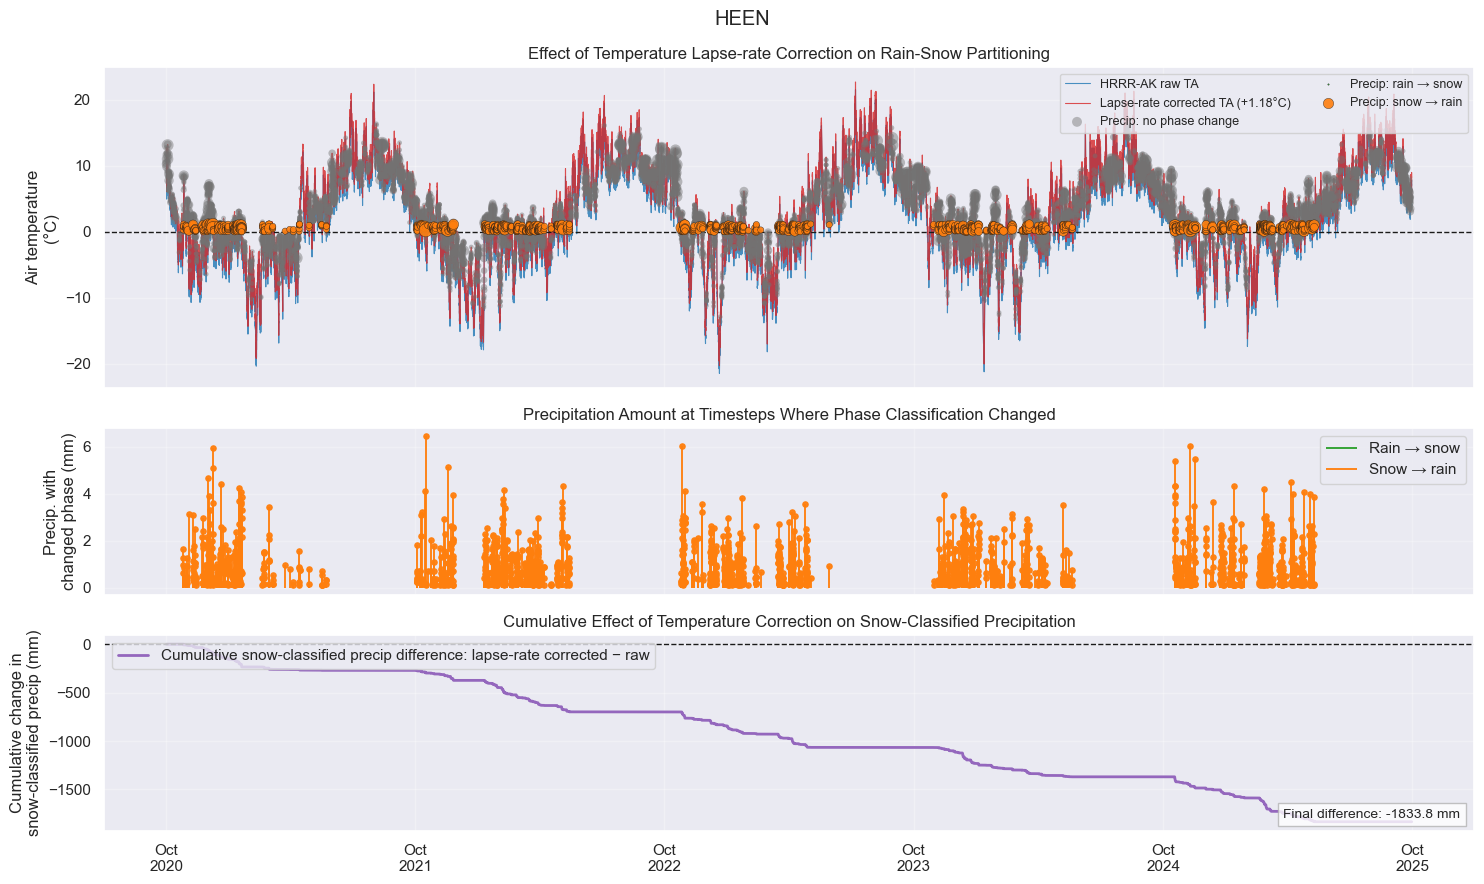

In [11]:
# =========================
# RAIN-SNOW PARTITIONING DIAGNOSTIC FIGURE
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------
# USER SETTINGS
# -------------------------
TEMP_THRESHOLD = 0.0
MIN_PRECIP = 0.1
PLOT_START = "2020-10-01"
PLOT_END = "2025-09-30"

# Optional colors
raw_color = "tab:blue"
lapse_color = "tab:red"
rain_to_snow_color = "tab:green"
snow_to_rain_color = "tab:orange"
no_change_color = "0.45"
cum_color = "tab:purple"

# -------------------------
# PREPARE DATA
# -------------------------
# Keep modeling TA in K elsewhere.
# Here, convert only for plotting and phase classification.
ta_raw_c = ds.temp.values - 273.15
ta_lapse_c = ta_raw_c + temperature_correction

df_part = pd.DataFrame(index=time)
df_part["TA_raw"] = ta_raw_c
df_part["TA_lapse"] = ta_lapse_c
df_part["PSUM"] = ds.precip_rate.values * TIMESTEP_SECONDS

# Match model timestep
df_part = df_part.resample(TIMESTEP).agg({
    "TA_raw": "mean",
    "TA_lapse": "mean",
    "PSUM": "sum"
})

df_part = df_part.loc[PLOT_START:PLOT_END].copy()

# -------------------------
# CLASSIFY PRECIPITATION PHASE
# -------------------------
precip_mask = df_part["PSUM"] >= MIN_PRECIP

df_part["phase_raw"] = np.where(df_part["TA_raw"] <= TEMP_THRESHOLD, "snow", "rain")
df_part["phase_lapse"] = np.where(df_part["TA_lapse"] <= TEMP_THRESHOLD, "snow", "rain")

df_part["change_type"] = "No precip / no change"

df_part.loc[
    precip_mask & (df_part["phase_raw"] == df_part["phase_lapse"]),
    "change_type"
] = "No phase change"

df_part.loc[
    precip_mask & (df_part["phase_raw"] == "rain") & (df_part["phase_lapse"] == "snow"),
    "change_type"
] = "Rain → snow"

df_part.loc[
    precip_mask & (df_part["phase_raw"] == "snow") & (df_part["phase_lapse"] == "rain"),
    "change_type"
] = "Snow → rain"

rain_to_snow_mask = df_part["change_type"] == "Rain → snow"
snow_to_rain_mask = df_part["change_type"] == "Snow → rain"
no_change_precip_mask = df_part["change_type"] == "No phase change"

# -------------------------
# SUMMARY VALUES
# -------------------------
df_part["snow_raw_mm"] = np.where(
    precip_mask & (df_part["phase_raw"] == "snow"),
    df_part["PSUM"],
    0.0
)

df_part["snow_lapse_mm"] = np.where(
    precip_mask & (df_part["phase_lapse"] == "snow"),
    df_part["PSUM"],
    0.0
)

df_part["cum_snow_raw"] = df_part["snow_raw_mm"].cumsum()
df_part["cum_snow_lapse"] = df_part["snow_lapse_mm"].cumsum()
df_part["cum_snow_difference"] = df_part["cum_snow_lapse"] - df_part["cum_snow_raw"]

total_precip = df_part.loc[precip_mask, "PSUM"].sum()
raw_snow_precip = df_part["snow_raw_mm"].sum()
lapse_snow_precip = df_part["snow_lapse_mm"].sum()
rain_to_snow = df_part.loc[rain_to_snow_mask, "PSUM"].sum()
snow_to_rain = df_part.loc[snow_to_rain_mask, "PSUM"].sum()

print("===== Rain-snow partitioning diagnostic =====")
print(f"Temperature correction applied: {temperature_correction:+.2f} °C / K")
print(f"Total precip during period: {total_precip:.1f} mm")
print(f"Raw HRRR snow-classified precip: {raw_snow_precip:.1f} mm")
print(f"Lapse-corrected snow-classified precip: {lapse_snow_precip:.1f} mm")
print(f"Net change in snow-classified precip: {lapse_snow_precip - raw_snow_precip:+.1f} mm")
print(f"Rain → snow precip: {rain_to_snow:.1f} mm")
print(f"Snow → rain precip: {snow_to_rain:.1f} mm")

# -------------------------
# PLOT
# -------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(15, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.2, 1.4]}
)

ax1, ax2, ax3 = axes

# =========================
# PANEL 1: TEMPERATURE + PRECIPITATING TIMESTEPS
# =========================
ax1.plot(
    df_part.index,
    df_part["TA_raw"],
    color=raw_color,
    linewidth=0.8,
    alpha=0.8,
    label="HRRR-AK raw TA"
)

ax1.plot(
    df_part.index,
    df_part["TA_lapse"],
    color=lapse_color,
    linewidth=0.8,
    alpha=0.8,
    label=f"Lapse-rate corrected TA ({temperature_correction:+.2f}°C)"
)

# Put precipitating timesteps on top of temperature lines
size_scale = np.clip(df_part.loc[precip_mask, "PSUM"] * 10, 12, 90)

ax1.scatter(
    df_part.loc[no_change_precip_mask].index,
    df_part.loc[no_change_precip_mask, "TA_lapse"],
    s=np.clip(df_part.loc[no_change_precip_mask, "PSUM"] * 10, 12, 90),
    color=no_change_color,
    alpha=0.45,
    edgecolor="none",
    zorder=5,
    label="Precip: no phase change"
)

ax1.scatter(
    df_part.loc[rain_to_snow_mask].index,
    df_part.loc[rain_to_snow_mask, "TA_lapse"],
    s=np.clip(df_part.loc[rain_to_snow_mask, "PSUM"] * 14, 20, 120),
    color=rain_to_snow_color,
    alpha=0.9,
    edgecolor="k",
    linewidth=0.3,
    zorder=6,
    label="Precip: rain → snow"
)

ax1.scatter(
    df_part.loc[snow_to_rain_mask].index,
    df_part.loc[snow_to_rain_mask, "TA_lapse"],
    s=np.clip(df_part.loc[snow_to_rain_mask, "PSUM"] * 14, 20, 120),
    color=snow_to_rain_color,
    alpha=0.9,
    edgecolor="k",
    linewidth=0.3,
    zorder=6,
    label="Precip: snow → rain"
)

ax1.axhline(TEMP_THRESHOLD, color="k", linestyle="--", linewidth=1)
ax1.set_ylabel("Air temperature\n(°C)")
ax1.set_title("Effect of Temperature Lapse-rate Correction on Rain-Snow Partitioning")
ax1.legend(loc="upper right", ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

# =========================
# PANEL 2: PRECIP WHERE PHASE CHANGED
# =========================
ax2.vlines(
    df_part.loc[rain_to_snow_mask].index,
    ymin=0,
    ymax=df_part.loc[rain_to_snow_mask, "PSUM"],
    color=rain_to_snow_color,
    linewidth=1.4,
    alpha=0.95,
    label="Rain → snow"
)

ax2.vlines(
    df_part.loc[snow_to_rain_mask].index,
    ymin=0,
    ymax=df_part.loc[snow_to_rain_mask, "PSUM"],
    color=snow_to_rain_color,
    linewidth=1.4,
    alpha=0.95,
    label="Snow → rain"
)

ax2.scatter(
    df_part.loc[rain_to_snow_mask].index,
    df_part.loc[rain_to_snow_mask, "PSUM"],
    color=rain_to_snow_color,
    s=14,
    alpha=0.95,
    zorder=4
)

ax2.scatter(
    df_part.loc[snow_to_rain_mask].index,
    df_part.loc[snow_to_rain_mask, "PSUM"],
    color=snow_to_rain_color,
    s=14,
    alpha=0.95,
    zorder=4
)

ax2.set_ylabel("Precip. with\nchanged phase (mm)")
ax2.set_title("Precipitation Amount at Timesteps Where Phase Classification Changed")
ax2.legend(loc="upper right")
ax2.grid(alpha=0.25)

# =========================
# PANEL 3: CUMULATIVE CHANGE IN SNOW-CLASSIFIED PRECIP
# =========================
ax3.plot(
    df_part.index,
    df_part["cum_snow_difference"],
    color=cum_color,
    linewidth=2,
    label="Cumulative snow-classified precip difference: lapse-rate corrected − raw"
)

ax3.axhline(0, color="k", linestyle="--", linewidth=1)

ax3.set_ylabel("Cumulative change in\nsnow-classified precip (mm)")
ax3.set_title("Cumulative Effect of Temperature Correction on Snow-Classified Precipitation")
ax3.legend(loc="upper left")
ax3.grid(alpha=0.3)

# Optional text annotation
final_diff = df_part["cum_snow_difference"].iloc[-1]
ax3.text(
    0.99,
    0.05,
    f"Final difference: {final_diff:+.1f} mm",
    transform=ax3.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.8)
)

# -------------------------
# FORMAT X-AXIS
# -------------------------
ax3.xaxis.set_major_locator(mdates.YearLocator(month=10))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("Oct\n%Y"))

plt.suptitle('HEEN')

plt.tight_layout()
plt.show()